In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

In [7]:
gpkg_path = "CostLayer/CostLayer_extent_small_polygon.gpkg"

cost_gdf = gpd.read_file(gpkg_path)
print(cost_gdf.crs)
print(cost_gdf.shape)
print(cost_gdf.head())


EPSG:3067
(687107, 2)
      VALUE                                           geometry
0  0.504041  POLYGON ((633263.079 7304168.981, 633273.08 73...
1  0.503585  POLYGON ((633273.08 7304168.981, 633283.081 73...
2  0.504018  POLYGON ((633283.081 7304168.981, 633293.081 7...
3  0.504755  POLYGON ((633293.081 7304168.981, 633303.082 7...
4  0.504204  POLYGON ((633303.082 7304168.981, 633313.083 7...


(632815.5477503254, 642661.2388264514, 7299233.155242503, 7304414.496725475)

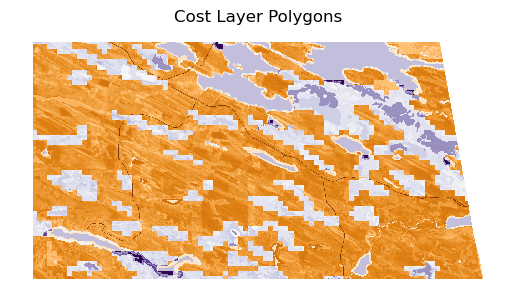

In [12]:
ax = cost_gdf[:400000].plot(column='VALUE', k=5, cmap='PuOr', linewidth=0)
plt.title("Cost Layer Polygons")
ax.axis(False)

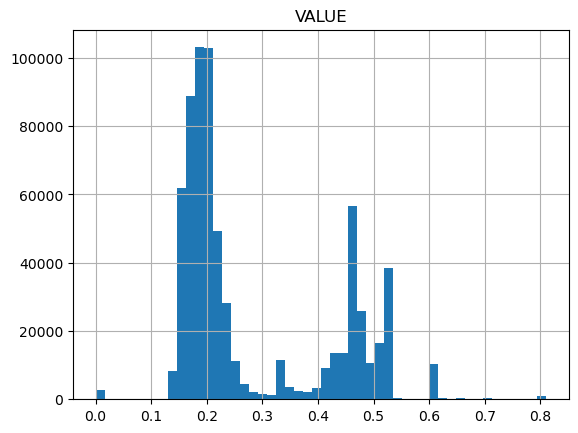

In [15]:
ax = cost_gdf.hist(bins=50)

# CLASSIFY CLASSES

In [16]:
import mapclassify

In [17]:
print(cost_gdf[['VALUE']].describe())

               VALUE
count  687107.000000
mean        0.281964
std         0.140196
min         0.000015
25%         0.180238
50%         0.206049
75%         0.443164
max         0.810728


In [20]:
print(cost_gdf[['VALUE']].isna().sum())

VALUE    0
dtype: int64


In [21]:
classifier = mapclassify.NaturalBreaks(cost_gdf['VALUE'], k=6)

In [22]:
print("Class Breaks:")
print(classifier.bins)

Class Breaks:
[0.18750152 0.27357954 0.39636067 0.48820242 0.57431191 0.81072837]


In [23]:
cost_gdf['NB_class'] = classifier.yb

In [25]:
for i in range(len(classifier.bins)):
    
    lower = classifier.bins[i-1] if i > 0 else cost_gdf['VALUE'].min()
    upper = classifier.bins[i]
    
    print(f"Class {i}: {lower:.2f} – {upper:.2f}")

Class 0: 0.00 – 0.19
Class 1: 0.19 – 0.27
Class 2: 0.27 – 0.40
Class 3: 0.40 – 0.49
Class 4: 0.49 – 0.57
Class 5: 0.57 – 0.81


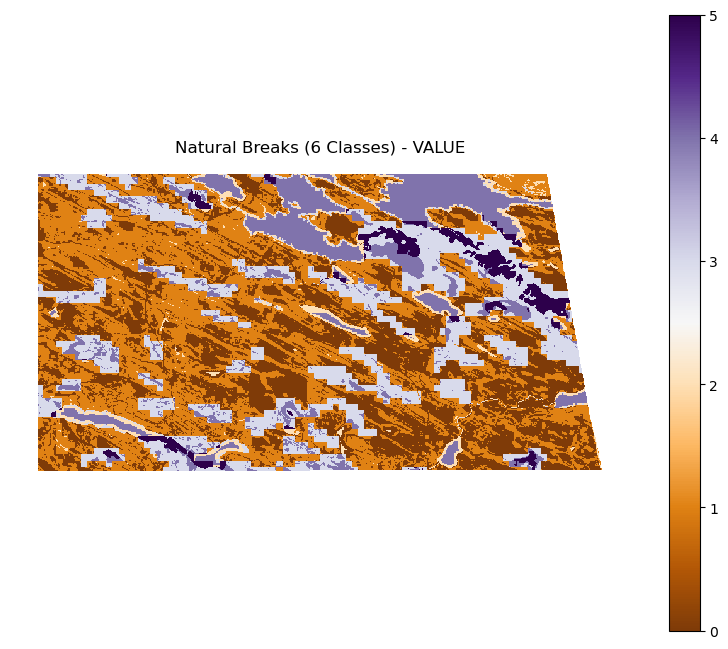

In [30]:
cost_gdf[:400000].plot(
                        column='NB_class',
                        cmap='PuOr',
                        legend=True,
                        figsize=(10, 8),
                        linewidth=0
                        )
plt.title("Natural Breaks (6 Classes) - VALUE")
plt.axis('off')
plt.show()

# DISSOLVE

In [31]:
dissolved_gdf = cost_gdf.dissolve(
                                by='NB_class',
                                aggfunc='mean'   # or 'min', 'max', 'median' - no matter here
                            )

In [33]:
dissolved_gdf = dissolved_gdf.reset_index()

In [39]:
dissolved_gdf

,NB_class,geometry,VALUE
0,0,"MULTIPOLYGON (((633333.084 7296498.475, 633343...",0.165352
1,1,"MULTIPOLYGON (((633343.085 7296448.472, 633343...",0.209710
2,2,"MULTIPOLYGON (((633473.094 7297088.514, 633473...",0.337129
3,3,"MULTIPOLYGON (((633263.079 7296388.468, 633263...",0.455214
4,4,"MULTIPOLYGON (((633293.081 7296368.466, 633283...",0.521091
5,5,"MULTIPOLYGON (((633453.093 7296368.466, 633443...",0.627968


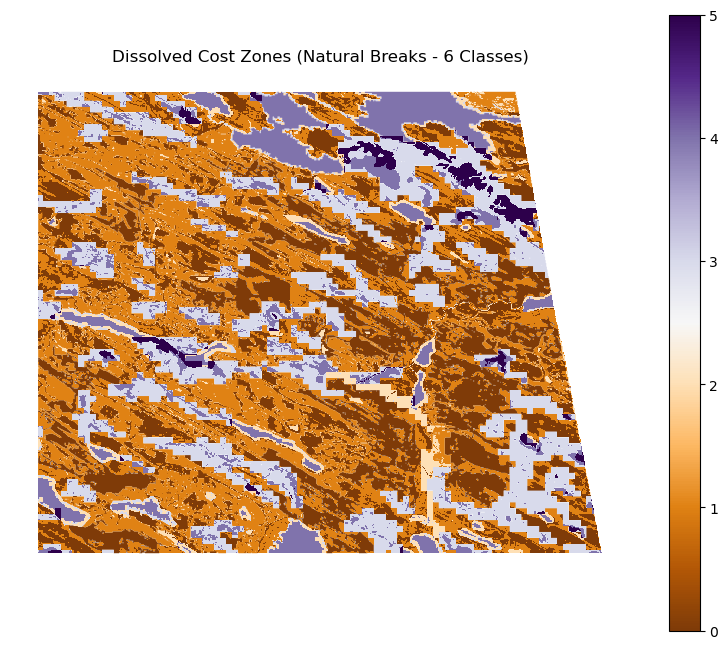

In [38]:
# fig, ax = plt.subplots(figsize=(10, 8))

ax = dissolved_gdf.plot(
                column='NB_class',
                cmap='PuOr',
                legend=True,
                figsize=(10, 8),
                linewidth=0
                )

ax.set_title("Dissolved Cost Zones (Natural Breaks - 6 Classes)")
ax.set_axis_off()

plt.show()

# MOBILITY COST

In [53]:
mobility_labels = {
    0: "0 Easy",
    1: "1 Low difficulty",
    2: "2 Moderate difficulty",
    3: "3 Difficult",
    4: "4 Very difficult",
    5: "5 Non-passable"
}

dissolved_gdf['mobility_cost'] = dissolved_gdf['NB_class'].map(mobility_labels)

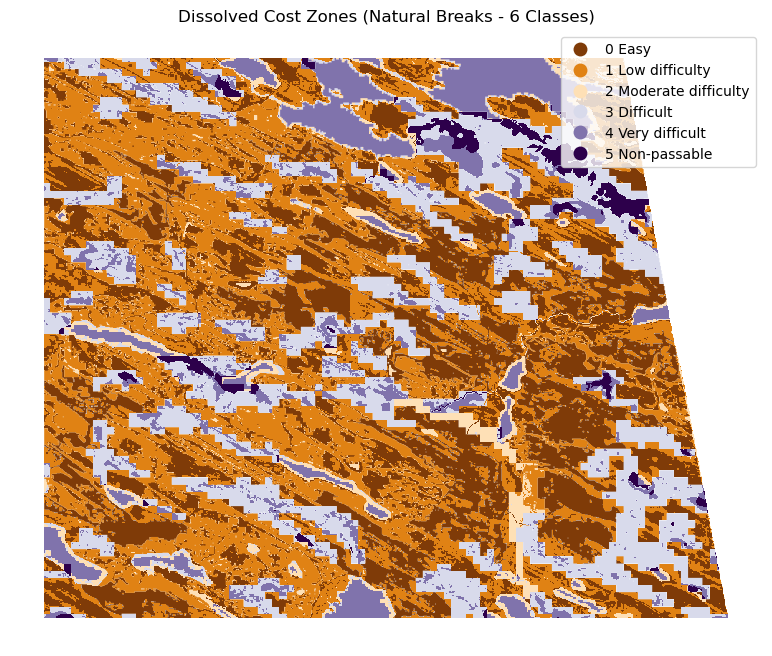

In [66]:
# fig, ax = plt.subplots(figsize=(10, 8))

ax = dissolved_gdf.plot(
                column='mobility_cost',
    categorical=True,
                cmap='PuOr',
                legend=True,
                figsize=(10, 8),
                linewidth=0
                )

ax.set_title("Dissolved Cost Zones (Natural Breaks - 6 Classes)")
ax.set_axis_off()

plt.savefig("mobility_cost_zones.png", dpi=300)

plt.show()

In [55]:
to_save = dissolved_gdf[['NB_class', 'mobility_cost', 'geometry']]

In [56]:
to_save.head()

,NB_class,mobility_cost,geometry
0,0,0 Easy,"MULTIPOLYGON (((633333.084 7296498.475, 633343..."
1,1,1 Low difficulty,"MULTIPOLYGON (((633343.085 7296448.472, 633343..."
2,2,2 Moderate difficulty,"MULTIPOLYGON (((633473.094 7297088.514, 633473..."
3,3,3 Difficult,"MULTIPOLYGON (((633263.079 7296388.468, 633263..."
4,4,4 Very difficult,"MULTIPOLYGON (((633293.081 7296368.466, 633283..."


In [63]:
to_save_geo = to_save.to_crs(4326)

In [64]:
to_save_geo.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [58]:
# clean_gdf = to_save.explode(index_parts=False).reset_index(drop=True)

In [59]:
# clean_gdf['geometry'] = clean_gdf.make_valid()

In [61]:
# print(clean_gdf.is_valid.value_counts())

True    10838
Name: count, dtype: int64


In [65]:
to_save_geo.to_file('CostLayer/to_webmap_CostLayer_extent_small.gpkg')
to_save_geo.to_file('CostLayer/to_webmap_CostLayer_extent_small.geojson', driver='GeoJSON')